# Task 2: Credit Risk Prediction

___________

## Problem Statement

The objective is to predict whether a loan applicant is likely to default on a loan. This is a binary
classification problem — the model outputs either Default or No Default. We use the Loan Prediction
Dataset available on Kaggle.

### Step 1: Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
%matplotlib inline
print("Libraries imported!")

Libraries imported!


### Step 2: Load the Dataset

In [5]:
# Load the dataset
df = pd.read_csv('C://Users//admin//OneDrive//Documents//GitHub//developershub-datascience-internship//Task2-Credit-Risk-Prediction//loan_dataset_20000.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (20000, 22)

First 5 rows:


,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


### Step 3: Dataset Understanding

In [10]:
# Column names and data types
print("Columns:", list(df.columns))

print("\nData types:")
print(df.dtypes)

# Statistical summary
print("\nStatistical Summary:")
print(df.describe().round(2))

# Count of loan paid back vs not paid back
print("\nLoan Paid Back counts:")
print(df['loan_paid_back'].value_counts())

# Check missing values
print("\nMissing values per column:")
print(df.isnull().sum())

Columns: ['age', 'gender', 'marital_status', 'education_level', 'annual_income', 'monthly_income', 'employment_status', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'loan_purpose', 'interest_rate', 'loan_term', 'installment', 'grade_subgrade', 'num_of_open_accounts', 'total_credit_limit', 'current_balance', 'delinquency_history', 'public_records', 'num_of_delinquencies', 'loan_paid_back']

Data types:
age                       int64
gender                   object
marital_status           object
education_level          object
annual_income           float64
monthly_income          float64
employment_status        object
debt_to_income_ratio    float64
credit_score              int64
loan_amount             float64
loan_purpose             object
interest_rate           float64
loan_term                 int64
installment             float64
grade_subgrade           object
num_of_open_accounts      int64
total_credit_limit      float64
current_balance         float64
delinquen

### Step 4: Data Cleaning — Handle Missing Values

In [12]:
# Fill missing values in numeric columns with median

num_cols = [
    'age', 'annual_income', 'monthly_income',
    'debt_to_income_ratio', 'credit_score',
    'loan_amount', 'interest_rate',
    'installment', 'total_credit_limit',
    'current_balance'
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing values in categorical columns with mode

cat_cols = [
    'gender',
    'marital_status',
    'education_level',
    'employment_status',
    'loan_purpose',
    'grade_subgrade'
]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Confirm no missing values remain

print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nAll missing values handled!")

Missing values after cleaning:
age                     0
gender                  0
marital_status          0
education_level         0
annual_income           0
monthly_income          0
employment_status       0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
loan_purpose            0
interest_rate           0
loan_term               0
installment             0
grade_subgrade          0
num_of_open_accounts    0
total_credit_limit      0
current_balance         0
delinquency_history     0
public_records          0
num_of_delinquencies    0
loan_paid_back          0
dtype: int64

All missing values handled!


### Step 5: Exploratory Data Analysis (EDA)

- Visualization 1 — Loan Paid Back Count

C:\Users\admin\AppData\Local\Temp\ipykernel_13008\1216678965.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


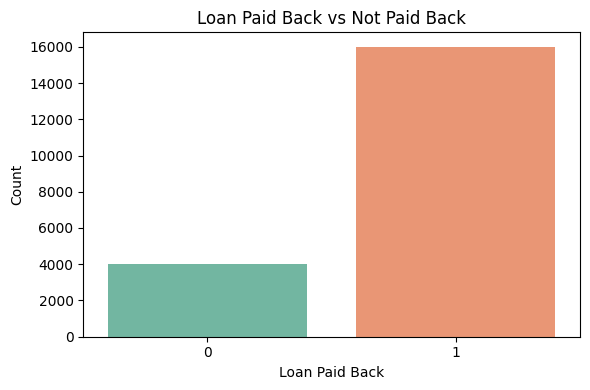

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='loan_paid_back',
    palette='Set2'
)

plt.title('Loan Paid Back vs Not Paid Back')
plt.xlabel('Loan Paid Back')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('loan_paid_back.png', dpi=150)
plt.show()

- Visualization 2 — Loan Amount Distribution

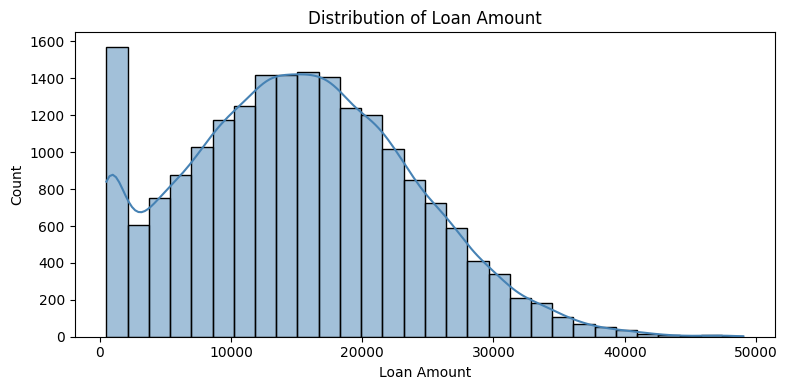

In [14]:
plt.figure(figsize=(8,4))

sns.histplot(
    df['loan_amount'],
    bins=30,
    kde=True,
    color='steelblue'
)

plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('loan_amount_dist.png', dpi=150)
plt.show()

- Visualization 3 — Loan Amount by Education Level

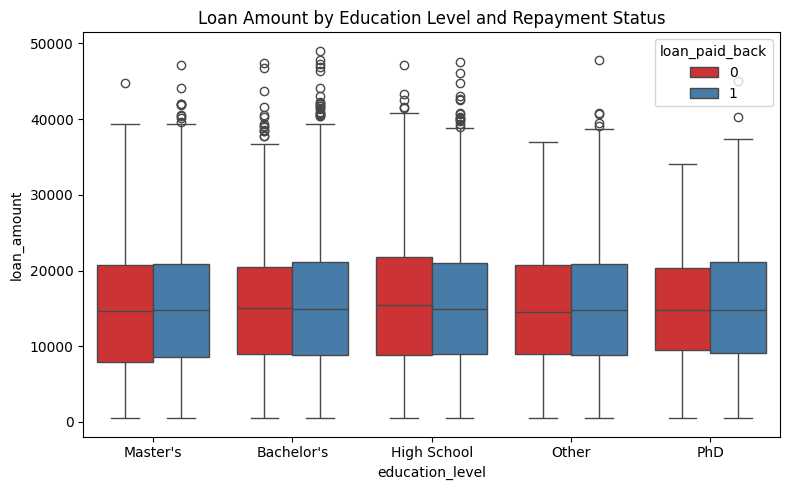

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='education_level',
    y='loan_amount',
    hue='loan_paid_back',
    palette='Set1'
)

plt.title('Loan Amount by Education Level and Repayment Status')

plt.tight_layout()
plt.savefig('loan_education.png', dpi=150)
plt.show()

- Visualization 4 — Monthly Income vs Loan Amount

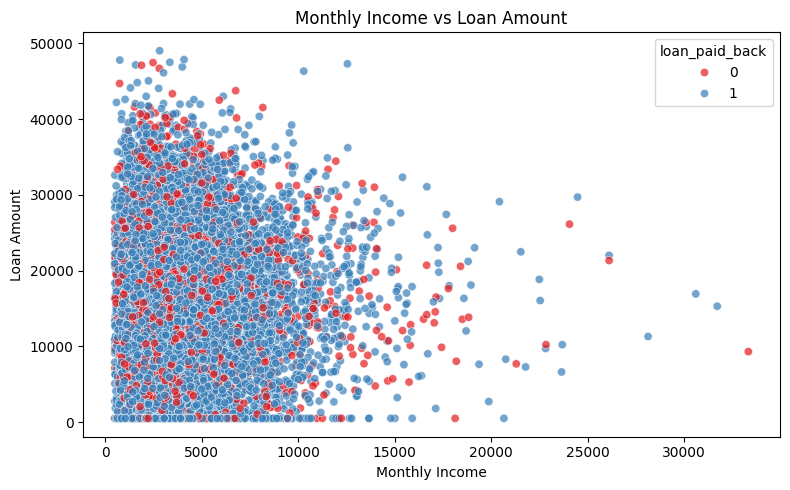

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='monthly_income',
    y='loan_amount',
    hue='loan_paid_back',
    palette='Set1',
    alpha=0.7
)

plt.title('Monthly Income vs Loan Amount')
plt.xlabel('Monthly Income')
plt.ylabel('Loan Amount')

plt.tight_layout()
plt.savefig('income_vs_loan.png', dpi=150)
plt.show()

### Step 6: Encode Categorical Features

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# List of categorical columns to encode

cat_cols = [
    'gender',
    'marital_status',
    'education_level',
    'employment_status',
    'loan_purpose',
    'grade_subgrade'
]

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Encoding complete! Preview:")
print(df.head())

Encoding complete! Preview:
   age  gender  marital_status  education_level  annual_income  \
0   59       1               1                2       24240.19   
1   72       0               1                0       20172.98   
2   49       0               2                1       26181.80   
3   35       0               2                1       11873.84   
4   63       2               2                3       25326.44   

   monthly_income  employment_status  debt_to_income_ratio  credit_score  \
0         2020.02                  0                 0.074           743   
1         1681.08                  0                 0.219           531   
2         2181.82                  0                 0.234           779   
3          989.49                  0                 0.264           809   
4         2110.54                  0                 0.260           663   

   loan_amount  ...  loan_term  installment  grade_subgrade  \
0     17173.72  ...         36       581.88            

### Step 7: Prepare Features and Split Data

In [18]:
# X = input features
# y = target column

X = df.drop('loan_paid_back', axis=1)
y = df['loan_paid_back']

print("Feature columns:", list(X.columns))
print("Target:", y.name)

# Split: 80% training, 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Feature columns: ['age', 'gender', 'marital_status', 'education_level', 'annual_income', 'monthly_income', 'employment_status', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'loan_purpose', 'interest_rate', 'loan_term', 'installment', 'grade_subgrade', 'num_of_open_accounts', 'total_credit_limit', 'current_balance', 'delinquency_history', 'public_records', 'num_of_delinquencies']
Target: loan_paid_back

Training samples: 16000
Testing samples: 4000


### Step 8: Train Classification Models

- Model A — Logistic Regression

In [19]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_preds)

print(f"Logistic Regression Accuracy: {lr_acc:.2%}")

c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 87.28%


- Model B — Decision Tree

In [20]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_preds)

print(f"Decision Tree Accuracy: {dt_acc:.2%}")

Decision Tree Accuracy: 89.30%


### Step 9: Evaluate Models — Confusion Matrix

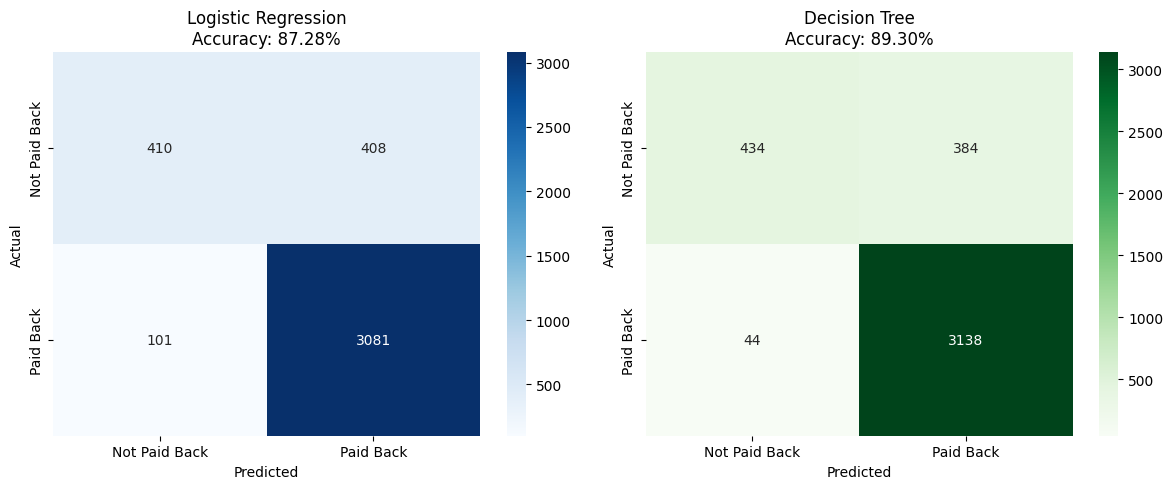

=== Logistic Regression Report ===
               precision    recall  f1-score   support

Not Paid Back       0.80      0.50      0.62       818
    Paid Back       0.88      0.97      0.92      3182

     accuracy                           0.87      4000
    macro avg       0.84      0.73      0.77      4000
 weighted avg       0.87      0.87      0.86      4000

=== Decision Tree Report ===
               precision    recall  f1-score   support

Not Paid Back       0.91      0.53      0.67       818
    Paid Back       0.89      0.99      0.94      3182

     accuracy                           0.89      4000
    macro avg       0.90      0.76      0.80      4000
 weighted avg       0.89      0.89      0.88      4000



In [21]:
plt.figure(figsize=(12,5))

# Logistic Regression

plt.subplot(1,2,1)

cm_lr = confusion_matrix(y_test, lr_preds)

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Paid Back','Paid Back'],
    yticklabels=['Not Paid Back','Paid Back']
)

plt.title(f'Logistic Regression\nAccuracy: {lr_acc:.2%}')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Decision Tree

plt.subplot(1,2,2)

cm_dt = confusion_matrix(y_test, dt_preds)

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Not Paid Back','Paid Back'],
    yticklabels=['Not Paid Back','Paid Back']
)

plt.title(f'Decision Tree\nAccuracy: {dt_acc:.2%}')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

# Full Classification Reports

print("=== Logistic Regression Report ===")
print(classification_report(
    y_test,
    lr_preds,
    target_names=['Not Paid Back', 'Paid Back']
))

print("=== Decision Tree Report ===")
print(classification_report(
    y_test,
    dt_preds,
    target_names=['Not Paid Back', 'Paid Back']
))

### Step 10: Conclusion — Key Insights

• **Missing values** were handled using median (numeric) and mode (categorical) imputation.

• **Credit Score** and Debt-to-Income Ratio are important indicators of loan repayment behavior.

• **Applicants with higher income** generally qualify for larger loans.

• **Logistic Regression** provides a strong baseline for loan repayment prediction.

• **Decision Tree** captures non-linear relationships but may overfit if depth is not controlled.

• **Confusion matrices** help identify whether the model struggles more with paid-back or non-paid-back loans.